In [ ]:
!pip install -q pandas numpy scipy matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

In [ ]:
url = "https://datahub.io/core/eeg-eye-state/_r/-/data/eeg-eye-state.csv"

df = pd.read_csv(url)

print(df.head())
print(df.shape)

       AF3       F7       F3      FC5       T7        P       O1       O2  \
0  4329.23  4009.23  4289.23  4148.21  4350.26  4586.15  4096.92  4641.03   
1  4324.62  4004.62  4293.85  4148.72  4342.05  4586.67  4097.44  4638.97   
2  4327.69  4006.67  4295.38  4156.41  4336.92  4583.59  4096.92  4630.26   
3  4328.72  4011.79  4296.41  4155.90  4343.59  4582.56  4097.44  4630.77   
4  4326.15  4011.79  4292.31  4151.28  4347.69  4586.67  4095.90  4627.69   

        P8       T8      FC6       F4       F8      AF4  class  
0  4222.05  4238.46  4211.28  4280.51  4635.90  4393.85      0  
1  4210.77  4226.67  4207.69  4279.49  4632.82  4384.10      0  
2  4207.69  4222.05  4206.67  4282.05  4628.72  4389.23      0  
3  4217.44  4235.38  4210.77  4287.69  4632.31  4396.41      0  
4  4210.77  4244.10  4212.82  4288.21  4632.82  4398.46      0  
(14980, 15)


In [ ]:
eeg = df["O1"].values

print("Number of samples:", len(eeg))

Number of samples: 14980


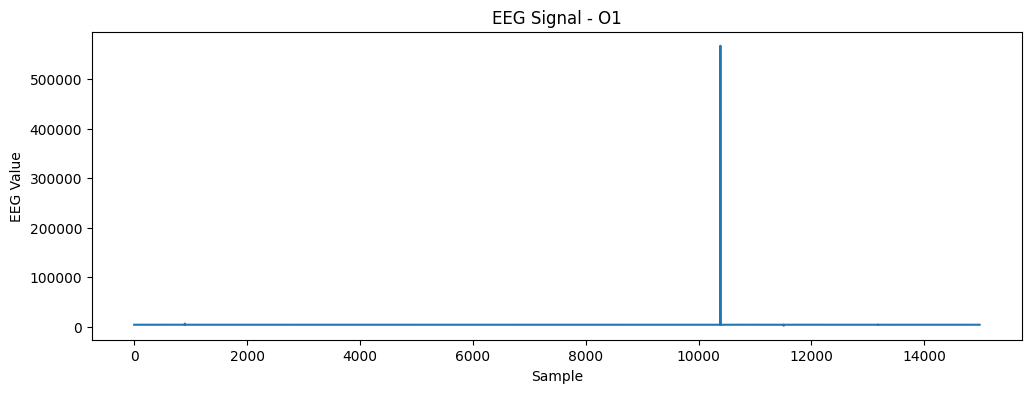

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(eeg)

plt.title("EEG Signal - O1")
plt.xlabel("Sample")
plt.ylabel("EEG Value")

plt.show()

In [ ]:
fs = 128

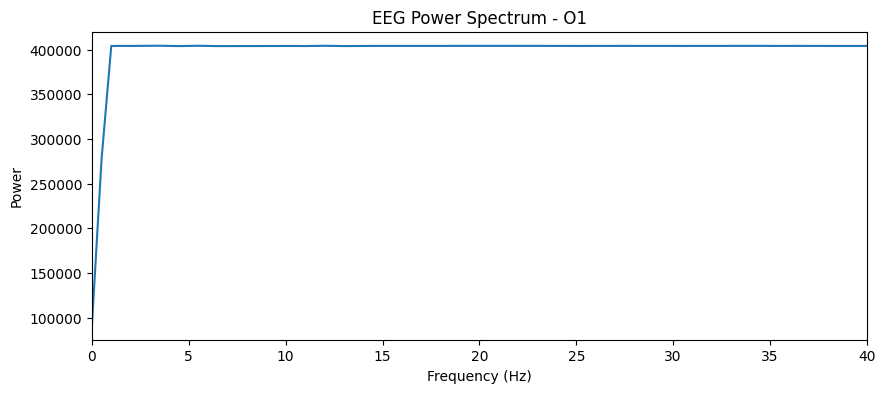

In [ ]:
f, pxx = welch(
    eeg,
    fs=fs,
    nperseg=256
)

plt.figure(figsize=(10,4))

plt.plot(f, pxx)

plt.xlim(0, 40)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")

plt.title("EEG Power Spectrum - O1")

plt.show()

In [ ]:
alpha = pxx[
    (f >= 8) & (f < 13)
].sum()

print("Alpha Power:", alpha)

Alpha Power: 4042527.310926152


In [ ]:
beta = pxx[
    (f >= 13) & (f < 30)
].sum()

print("Beta Power:", beta)

Beta Power: 13745623.539412035


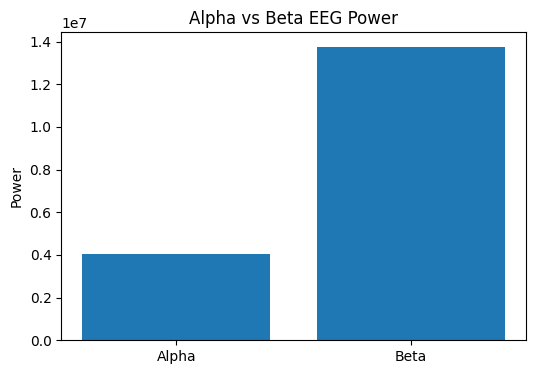

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Alpha", "Beta"],
    [alpha, beta]
)

plt.ylabel("Power")
plt.title("Alpha vs Beta EEG Power")

plt.show()

In [ ]:
print(df["class"].value_counts())

class
0    8257
1    6723
Name: count, dtype: int64


In [ ]:
print(
    df.groupby("class")["O1"].mean()
)

class
0    4140.387390
1    4073.570684
Name: O1, dtype: float64


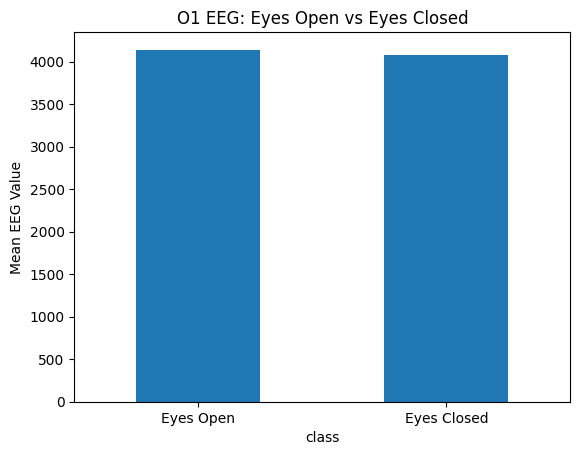

In [ ]:
df.groupby("class")["O1"].mean().plot(
    kind="bar"
)

plt.xticks(
    [0, 1],
    ["Eyes Open", "Eyes Closed"],
    rotation=0
)

plt.ylabel("Mean EEG Value")
plt.title("O1 EEG: Eyes Open vs Eyes Closed")

plt.show()